In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv


In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv(r"/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv")

In [2]:
df.head()

NameError: name 'df' is not defined

In [6]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [8]:
df.shape


(17966, 9)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [12]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [13]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [ ]:
#EDA
#price


<Axes: xlabel='price', ylabel='Count'>

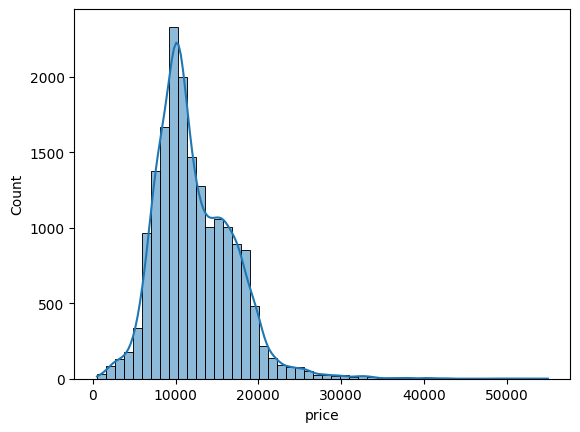

In [19]:
sns.histplot(df['price'],bins = 50 , kde = 2)

<Axes: xlabel='year', ylabel='price'>

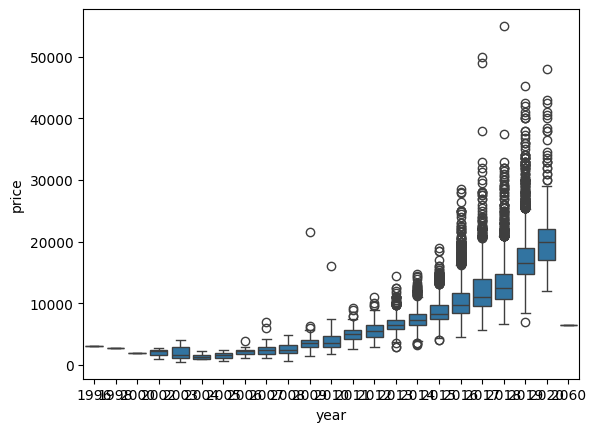

In [31]:
sns.boxplot(data = df , x='year', y = 'price')


<Axes: xlabel='mileage', ylabel='price'>

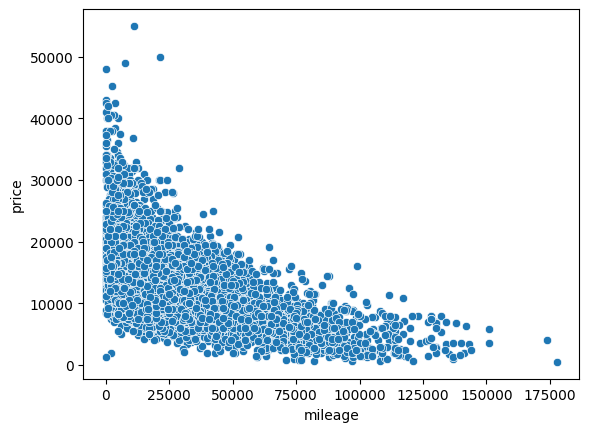

In [32]:
sns.scatterplot(data = df, x= 'mileage' , y='price')

<Axes: xlabel='engineSize', ylabel='price'>

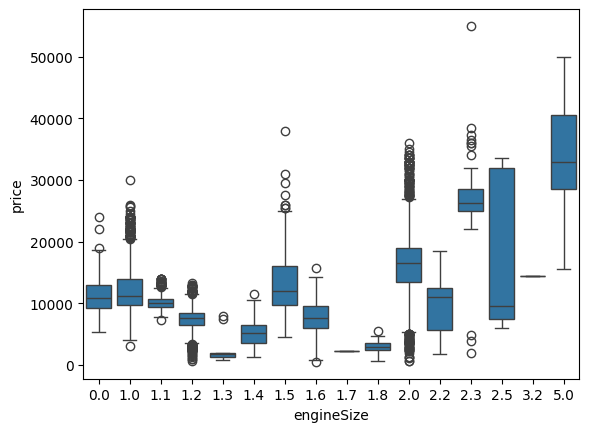

In [35]:
sns.boxplot( data = df,x='engineSize' , y='price')

In [37]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

<Axes: xlabel='transmission', ylabel='price'>

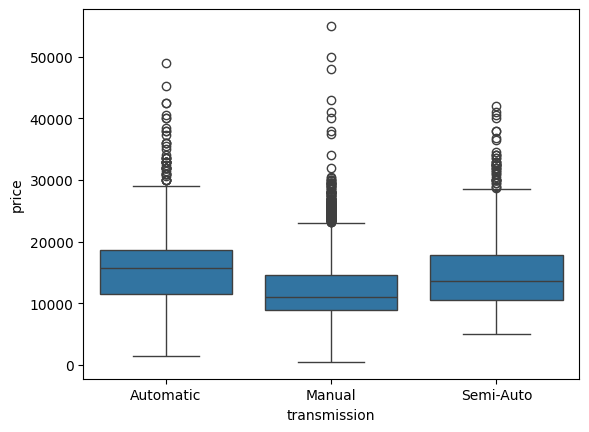

In [39]:
sns.boxplot(data = df , x='transmission' , y='price')

<Axes: xlabel='fuelType', ylabel='price'>

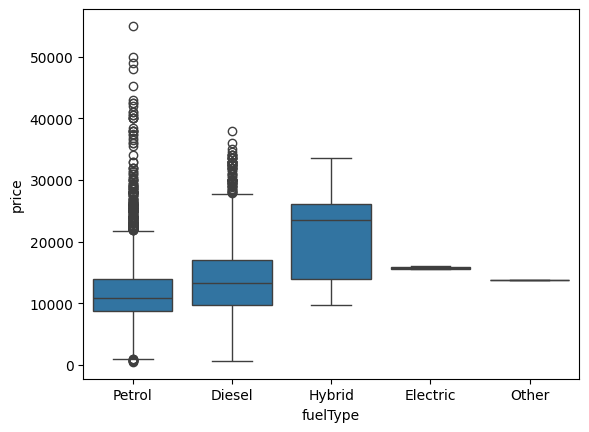

In [44]:
sns.boxplot(data = df , x='fuelType' , y = 'price')

<Axes: xlabel='model', ylabel='price'>

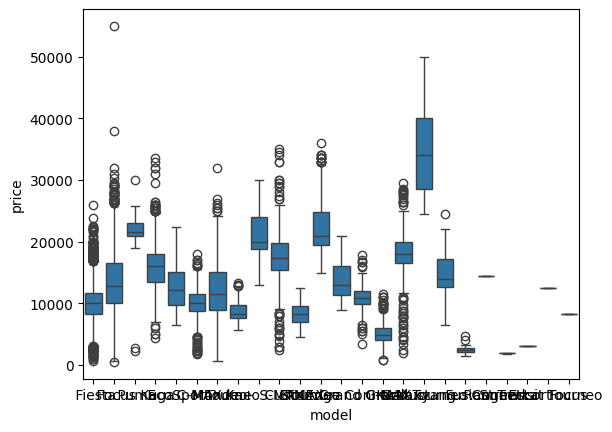

In [46]:
sns.boxplot(x=df['model'],y=df['price'])

In [48]:
X = df.drop(columns = ['price'] , axis = 1)
y = df['price']
X

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,Manual,5007,Petrol,145,57.7,1.2


In [54]:
X_one_encode = pd.get_dummies(X,columns = ['model','transmission','fuelType'],drop_first = True)

In [62]:
X_one_encode = X_one_encode.astype(int)

NameError: name 'X_one_encode' is not defined

In [64]:
X_one_encode

NameError: name 'X_one_encode' is not defined

In [66]:
from sklearn.preprocessing import LabelEncoder
encode = LabelEncoder()

In [69]:
columns = ['model','transmission','fuelType']
Xlabel = X

In [71]:
Xlabel

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,Manual,5007,Petrol,145,57.7,1.2


In [78]:
for i in columns:
    Xlabel[i]=encode.fit_transform(Xlabel[i])

In [82]:
Xlabel

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,0,2017,0,15944,0,150,57.7,1.0
1,0,2018,0,9083,0,150,57.7,1.0
2,0,2017,0,12456,0,150,57.7,1.0
3,0,2019,0,10460,0,145,40.3,1.5
4,0,2019,0,1482,0,145,48.7,1.0
...,...,...,...,...,...,...,...,...
17961,0,2017,0,16700,0,150,47.1,1.4
17962,0,2014,0,40700,0,30,57.7,1.0
17963,0,2015,0,7010,0,20,67.3,1.6
17964,0,2018,0,5007,0,145,57.7,1.2


In [84]:
df['model'].value_counts()

model
 Fiesta                   6557
 Focus                    4588
 Kuga                     2225
 EcoSport                 1143
 C-MAX                     543
 Ka+                       531
 Mondeo                    526
 B-MAX                     355
 S-MAX                     296
 Grand C-MAX               247
 Galaxy                    228
 Edge                      208
 KA                        199
 Puma                       80
 Tourneo Custom             69
 Grand Tourneo Connect      59
 Mustang                    57
 Tourneo Connect            33
 Fusion                     16
 Streetka                    2
 Ranger                      1
 Escort                      1
 Transit Tourneo             1
Focus                        1
Name: count, dtype: int64

In [88]:
from sklearn.preprocessing import StandardScalar

ImportError: cannot import name 'StandardScalar' from 'sklearn.preprocessing' (/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/__init__.py)

In [89]:
pip show scikit-learn

Name: scikit-learn
Version: 1.6.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: BSD 3-Clause License

 Copyright (c) 2007-2024 The scikit-learn developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED BY THE COPYR

In [98]:
from sklearn.preprocessing import StandardScaler

In [99]:
numerical_cols = ['year' , 'mileage' , 'tax' , 'mpg' , 'engineSize']
scaler = StandardScalar()
X_one_encode[numerical_cols] = scalar.fit_transform(X_one_encode[numerical_cols])

NameError: name 'StandardScalar' is not defined

In [102]:
Xlabel[''] = scalar.fit_transform(Xlabel)

NameError: name 'scalar' is not defined

In [103]:
Xlabel.columns

Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='object')

In [106]:
Xlabel[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize']] = scalar.fit_transform(Xlabel[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize']])

NameError: name 'scalar' is not defined

In [107]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression 
from sklearn.metrices import mean_absolute_error, mean_squared_error , r2_score

ModuleNotFoundError: No module named 'sklearn.metrices'

In [122]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [ ]:
X_train , X_test , y_train , y_test = train_test_split(X_one_encode , y, test_size = 0.33 , random_state= 42)

In [132]:
model.fit(X_train , y_train)model = LinearRegression()


NameError: name 'X_train' is not defined

In [129]:
y_pred = model.predict(X_train)
y_pred

NameError: name 'X_train' is not defined

In [ ]:
r2 = r2_score(y_test,y_pred)

In [133]:
n= X_test.shape[0]
p=X_test.shape[1]
adjusted_r2 = 1-((1-r2)*(n-1)/(n-p-1))
print("Adjusted R2 Score:",adjusted_r2)

NameError: name 'X_test' is not defined

In [136]:
X_train , X_test , y_train , y_test = train_test_split(Xlabel , y, test_size = 0.33 , random_state= 42)

In [140]:
model2 = LinearRegression()
model2.fit(X_train , y_train)



LinearRegression()

In [148]:
y_pred = model2.predict(X_test)

In [150]:
y_pred

array([ 6355.72282028,  9586.78832403,  9211.29702499, ...,
       18976.83142047,  8142.61037255,  9860.12559775], shape=(5929,))

In [152]:
y_test

17610     6995
7076      8999
1713      7998
1611      5491
16830     3790
         ...  
6015     19000
10301    10940
15006    21999
5396      6995
6087     10299
Name: price, Length: 5929, dtype: int64

In [153]:
r2 = r2_score(y_test , y_pred)
r2

0.7246904411329353